In [82]:
import pandas as pd

#is the shared start of the three web addresses, so we don't repeat it.
base = "https://huggingface.co/datasets/masakhane/masakhaner2/resolve/refs%2Fconvert%2Fparquet/twi"

train_df = pd.read_parquet(f"{base}/train/0000.parquet")
val_df   = pd.read_parquet(f"{base}/validation/0000.parquet")
test_df  = pd.read_parquet(f"{base}/test/0000.parquet")

print(len(train_df), len(val_df), len(test_df))
train_df.head()


4240 605 1211


,id,tokens,ner_tags
0,0,"[Mmom, obi, a, ɔwɔ, ahobrɛase, no, fi, ne, kom...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,1,"[Dr, ., Nikhil, Sharma, a, ɔfiri, Himachal, Pr...","[0, 0, 1, 2, 0, 0, 5, 6, 0, 0, 0, 0, 0, 0, 0, ..."
2,2,"[Nsu, a, ɛtɔ, denneennen, no, aka, nnipa, pii,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 5, 0, 5, 0, 5, 0, ..."
3,3,"[Owura, Asante, Bediatuo, sii, so, dua, biom, ...","[0, 1, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,4,"[Sɛ, yɛwɔ, tema, ma, obi, a, ,, yebehu, sɛ, ɛn...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"


In [83]:
# Tool that counts how often each item appears
from collections import Counter

# Put all words from all training sentences into one list
train_tokens = [word for sentence in train_df["tokens"] for word in sentence]

# Count how many times each word appears
word_counts = Counter(train_tokens)

# Show total words, distinct words, and words seen only once
print("Total tokens:", len(train_tokens))
print("Vocabulary size (types):", len(word_counts))
print("Words seen only once:", sum(1 for w, c in word_counts.items() if c == 1))
print()

# Show the 20 most common words
print("20 most common words:")
print(word_counts.most_common(20))


Total tokens: 112160
Vocabulary size (types): 11610
Words seen only once: 6305

20 most common words:
[('no', 6823), ('a', 5663), ('sɛ', 4312), (',', 4020), ('.', 3678), ('na', 2231), ('mu', 2217), ('ne', 2109), ('wɔn', 1793), ('wɔ', 1777), ('so', 1430), ('ho', 1317), ('yi', 1133), ('de', 869), ('bi', 737), ('saa', 628), ('nso', 559), ('yɛ', 533), ('adwuma', 506), ('hɔ', 476)]


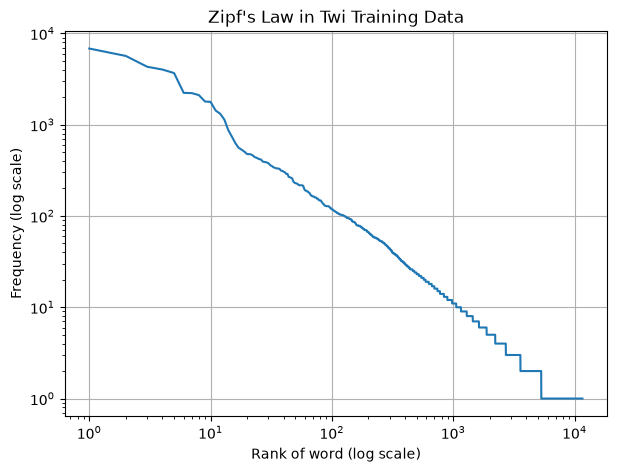

In [84]:
# Tool for drawing charts
import matplotlib.pyplot as plt

# Word frequencies sorted from most to least common
frequencies = [count for word, count in word_counts.most_common()]

# Ranks: 1 for the most common word, 2 for the next, and so on
ranks = range(1, len(frequencies) + 1)

# Plot rank against frequency on log-log axes
plt.figure(figsize=(7, 5))
plt.loglog(ranks, frequencies)
plt.xlabel("Rank of word (log scale)")
plt.ylabel("Frequency (log scale)")
plt.title("Zipf's Law in Twi Training Data")
plt.grid(True)
plt.show()


In [85]:
# Test Zipf: if rank and frequency are inversely proportional, rank × frequency stays roughly constant
for rank in [1, 2, 5, 10, 50, 100, 500, 1000, 5000]:
    word, freq = word_counts.most_common()[rank - 1]
    print(f"Rank {rank:>5} | {word:>12} | freq {freq:>5} | rank × freq = {rank * freq}")


Rank     1 |           no | freq  6823 | rank × freq = 6823
Rank     2 |            a | freq  5663 | rank × freq = 11326
Rank     5 |            . | freq  3678 | rank × freq = 18390
Rank    10 |           wɔ | freq  1777 | rank × freq = 17770
Rank    50 |           ka | freq   229 | rank × freq = 11450
Rank   100 |           Dr | freq   118 | rank × freq = 11800
Rank   500 |      wɔatumi | freq    23 | rank × freq = 11500
Rank  1000 |      atuateɛ | freq    11 | rank × freq = 11000
Rank  5000 |          End | freq     2 | rank × freq = 10000


In [86]:
# Lowercase every word and add start/end markers to each sentence
def preprocess(sentences):
    cleaned = []
    for sentence in sentences:
        words = [word.lower() for word in sentence if any(ch.isalnum() for ch in word)]
        cleaned.append(["<s>"] + words + ["</s>"])
    return cleaned

# Apply the same cleaning to all three splits
train_sents = preprocess(train_df["tokens"])
val_sents   = preprocess(val_df["tokens"])
test_sents  = preprocess(test_df["tokens"])

# Compare a sentence before and after cleaning
print("Before:", list(train_df["tokens"][0]))
print("After: ", train_sents[0])


Before: ['Mmom', 'obi', 'a', 'ɔwɔ', 'ahobrɛase', 'no', 'fi', 'ne', 'komam', 'dwen', 'afoforo', 'ho', ',', 'na', 'ɔwɔ', 'ɔpɛ', 'sɛ', 'obesua', 'biribi', 'afi', 'wɔn', 'hɔ', '.']
After:  ['<s>', 'mmom', 'obi', 'a', 'ɔwɔ', 'ahobrɛase', 'no', 'fi', 'ne', 'komam', 'dwen', 'afoforo', 'ho', 'na', 'ɔwɔ', 'ɔpɛ', 'sɛ', 'obesua', 'biribi', 'afi', 'wɔn', 'hɔ', '</s>']


In [87]:
# Count words in the cleaned training data
train_counts = Counter(word for sentence in train_sents for word in sentence)

# Vocabulary = words seen at least 2 times in training
vocab = {word for word, count in train_counts.items() if count >= 2}

# Replace any word not in the vocabulary with <UNK>
def replace_unk(sentences, vocab):
    return [[word if word in vocab else "<UNK>" for word in sentence] for sentence in sentences]

# Apply to all three splits, always using the TRAINING vocabulary
train_sents = replace_unk(train_sents, vocab)
val_sents   = replace_unk(val_sents, vocab)
test_sents  = replace_unk(test_sents, vocab)

# Check the results
print("Vocabulary size (incl. <UNK>):", len(vocab) + 1)
test_words = [word for sentence in test_sents for word in sentence]
print("Share of test words that are <UNK>:", round(test_words.count("<UNK>") / len(test_words) * 100, 1), "%")
print("Example:", train_sents[0])


Vocabulary size (incl. <UNK>): 4971
Share of test words that are <UNK>: 9.8 %
Example: ['<s>', 'mmom', 'obi', 'a', 'ɔwɔ', 'ahobrɛase', 'no', 'fi', 'ne', 'komam', 'dwen', 'afoforo', 'ho', 'na', 'ɔwɔ', 'ɔpɛ', 'sɛ', '<UNK>', 'biribi', 'afi', 'wɔn', 'hɔ', '</s>']


In [88]:
# Cut a sentence into N-grams: slide a window of n words along it
def get_ngrams(sentence, n):
    return [tuple(sentence[i:i + n]) for i in range(len(sentence) - n + 1)]

# Try it on a short example
example = ["<s>", "kofi", "kɔɔ", "fie", "</s>"]
print("Unigrams:", get_ngrams(example, 1))
print("Bigrams: ", get_ngrams(example, 2))
print("Trigrams:", get_ngrams(example, 3))


Unigrams: [('<s>',), ('kofi',), ('kɔɔ',), ('fie',), ('</s>',)]
Bigrams:  [('<s>', 'kofi'), ('kofi', 'kɔɔ'), ('kɔɔ', 'fie'), ('fie', '</s>')]
Trigrams: [('<s>', 'kofi', 'kɔɔ'), ('kofi', 'kɔɔ', 'fie'), ('kɔɔ', 'fie', '</s>')]


In [89]:
# Count all unigrams, bigrams and trigrams in the training data
unigram_counts = Counter(ng for s in train_sents for ng in get_ngrams(s, 1))
bigram_counts  = Counter(ng for s in train_sents for ng in get_ngrams(s, 2))
trigram_counts = Counter(ng for s in train_sents for ng in get_ngrams(s, 3))

# How many different N-grams of each size did we see?
print("Unique unigrams:", len(unigram_counts))
print("Unique bigrams: ", len(bigram_counts))
print("Unique trigrams:", len(trigram_counts))
print()

# The most common bigrams
print("10 most common bigrams:")
for bigram, count in bigram_counts.most_common(10):
    print(bigram, count)


Unique unigrams: 4971
Unique bigrams:  43507
Unique trigrams: 80012

10 most common bigrams:
('<UNK>', '<UNK>') 642
('no', 'mu') 633
('no', '</s>') 481
('mu', '</s>') 467
('sɛ', '<UNK>') 447
('<UNK>', 'no') 361
('<UNK>', 'a') 347
('a', '<UNK>') 346
('mu', 'no') 332
('wɔn', 'a') 292


In [90]:
# MLE bigram probability: P(word | prev) = count(prev, word) / count(prev)
def bigram_prob(prev, word):
    return bigram_counts[(prev, word)] / unigram_counts[(prev,)]

# Trying a few examples
print("P(mu | no)    =", round(bigram_prob("no", "mu"), 4))
print("P(</s> | no)  =", round(bigram_prob("no", "</s>"), 4))
print("P(a | wɔn)    =", round(bigram_prob("wɔn", "a"), 4))
print("P(kofi | no)  =", round(bigram_prob("no", "kofi"), 4))


P(mu | no)    = 0.0927
P(</s> | no)  = 0.0705
P(a | wɔn)    = 0.1567
P(kofi | no)  = 0.0


In [91]:
# Vocabulary size V (all unique words, including <s>, </s> and <UNK>)
V = len(unigram_counts)

# Laplace (add-one) bigram probability
def laplace_prob(prev, word):
    return (bigram_counts[(prev, word)] + 1) / (unigram_counts[(prev,)] + V)

# Compare MLE and Laplace on the same examples
for prev, word in [("no", "mu"), ("no", "</s>"), ("wɔn", "a"), ("no", "kofi")]:
    print(f"P({word} | {prev}):  MLE = {bigram_prob(prev, word):.4f}   Laplace = {laplace_prob(prev, word):.4f}")


P(mu | no):  MLE = 0.0927   Laplace = 0.0537
P(</s> | no):  MLE = 0.0705   Laplace = 0.0409
P(a | wɔn):  MLE = 0.1567   Laplace = 0.0429
P(kofi | no):  MLE = 0.0000   Laplace = 0.0001


In [92]:
#Loading Python's Math tools log and exp
import math

# Perplexity of a bigram model on a list of sentences (lower = better)
def perplexity(sentences, prob_fn):
    log_prob_sum = 0
    N = 0
    for sentence in sentences:
        for prev, word in get_ngrams(sentence, 2):
            log_prob_sum += math.log(prob_fn(prev, word))
            N += 1
    return math.exp(-log_prob_sum / N)

# Laplace bigram model on validation and test data
print("Laplace bigram, validation perplexity:", round(perplexity(val_sents, laplace_prob), 1))
print("Laplace bigram, test perplexity:      ", round(perplexity(test_sents, laplace_prob), 1))


Laplace bigram, validation perplexity: 870.3
Laplace bigram, test perplexity:       838.3


In [93]:
# Total words the model predicts (every token except <s>, which is never predicted)
total_words = sum(unigram_counts.values()) - unigram_counts[("<s>",)]

# Unigram probability: how common the word is, ignoring the previous word
def unigram_prob(prev, word):
    return unigram_counts[(word,)] / total_words

print("Unigram, validation perplexity:", round(perplexity(val_sents, unigram_prob), 1))
print("Unigram, test perplexity:      ", round(perplexity(test_sents, unigram_prob), 1))


Unigram, validation perplexity: 353.7
Unigram, test perplexity:       338.1


In [94]:
# Interpolation: mix the bigram (MLE) and unigram probabilities using weight lam
def interp_prob(prev, word, lam):
    return lam * bigram_prob(prev, word) + (1 - lam) * unigram_prob(prev, word)

# Try different weights on the VALIDATION set to find the best one
for lam in [0.1, 0.3, 0.5, 0.7, 0.9]:
    pp = perplexity(val_sents, lambda p, w: interp_prob(p, w, lam))
    print(f"lambda = {lam}:  validation perplexity = {pp:.1f}")


lambda = 0.1:  validation perplexity = 232.7
lambda = 0.3:  validation perplexity = 187.8
lambda = 0.5:  validation perplexity = 174.6
lambda = 0.7:  validation perplexity = 178.6
lambda = 0.9:  validation perplexity = 220.2


In [95]:
# Final evaluation on the TEST set, using the lambda chosen on validation
best_lam = 0.5
test_pp = perplexity(test_sents, lambda p, w: interp_prob(p, w, best_lam))

# Compare all models on the test set
print("Test perplexity by model:")
print("  Unigram:              ", round(perplexity(test_sents, unigram_prob), 1))
print("  Laplace bigram:       ", round(perplexity(test_sents, laplace_prob), 1))
print("  Interpolated bigram:  ", round(test_pp, 1))


Test perplexity by model:
  Unigram:               338.1
  Laplace bigram:        838.3
  Interpolated bigram:   167.0


In [96]:
# Add an extra <s> so the first word also has two previous words
train_tri = [["<s>"] + s for s in train_sents]

# Count trigrams, and count each word pair that is followed by another word (the trigram "context")
tri_counts = Counter(ng for s in train_tri for ng in get_ngrams(s, 3))
ctx_counts = Counter(ng for s in train_tri for ng in get_ngrams(s[:-1], 2))

# MLE trigram probability: count(w2 w1 word) / count(w2 w1); 0 if the pair was never seen
def trigram_prob(p2, p1, word):
    c = ctx_counts[(p2, p1)]
    return tri_counts[(p2, p1, word)] / c if c > 0 else 0.0

print("Unique trigrams (with padding):", len(tri_counts))
print("P(mu | ghana, no) =", round(trigram_prob("ghana", "no", "mu"), 4))


Unique trigrams (with padding): 81151
P(mu | ghana, no) = 0.0


In [97]:
# Interpolated trigram: blend trigram, bigram and unigram (weights sum to 1)
def interp3_prob(p2, p1, word, l3, l2):
    l1 = 1 - l3 - l2
    return l3 * trigram_prob(p2, p1, word) + l2 * bigram_prob(p1, word) + l1 * unigram_prob(None, word)

# Perplexity for a trigram model (adds the extra <s> so every word has two previous words)
def perplexity3(sentences, l3, l2):
    log_prob_sum, N = 0, 0
    for s in sentences:
        for p2, p1, word in get_ngrams(["<s>"] + s, 3):
            log_prob_sum += math.log(interp3_prob(p2, p1, word, l3, l2))
            N += 1
    return math.exp(-log_prob_sum / N)

# Try weight combinations on the VALIDATION set
for l3, l2 in [(0.1, 0.4), (0.2, 0.4), (0.3, 0.4), (0.2, 0.5), (0.3, 0.3)]:
    print(f"trigram={l3}, bigram={l2}, unigram={round(1-l3-l2, 1)}:  val perplexity = {perplexity3(val_sents, l3, l2):.1f}")


trigram=0.1, bigram=0.4, unigram=0.5:  val perplexity = 157.4
trigram=0.2, bigram=0.4, unigram=0.4:  val perplexity = 157.5
trigram=0.3, bigram=0.4, unigram=0.3:  val perplexity = 164.7
trigram=0.2, bigram=0.5, unigram=0.3:  val perplexity = 160.9
trigram=0.3, bigram=0.3, unigram=0.4:  val perplexity = 162.7


Unigram              338.1
Bigram (Laplace)     838.3
Bigram (interp.)     167.0
Trigram (interp.)    150.6


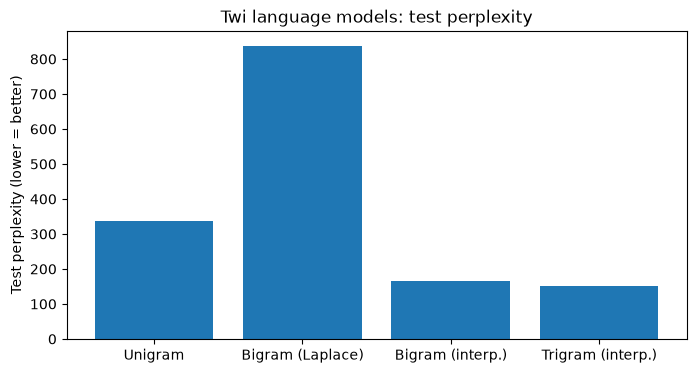

In [98]:
# Final test perplexity for every model, using settings chosen on validation
results = {
    "Unigram": perplexity(test_sents, unigram_prob),
    "Bigram (Laplace)": perplexity(test_sents, laplace_prob),
    "Bigram (interp.)": perplexity(test_sents, lambda p, w: interp_prob(p, w, 0.5)),
    "Trigram (interp.)": perplexity3(test_sents, 0.1, 0.4),
}

for model, pp in results.items():
    print(f"{model:20} {pp:.1f}")

# Bar chart comparing the models (lower is better)
plt.figure(figsize=(8, 4))
plt.bar(list(results.keys()), list(results.values()))   # list(...) turns names and scores into plain lists
plt.ylabel("Test perplexity (lower = better)")
plt.title("Twi language models: test perplexity")
plt.savefig("perplexity_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


 10% of training data (424 sentences): val perplexity = 343.8
 25% of training data (1060 sentences): val perplexity = 254.2
 50% of training data (2120 sentences): val perplexity = 210.6
 75% of training data (3180 sentences): val perplexity = 186.0
100% of training data (4240 sentences): val perplexity = 174.2


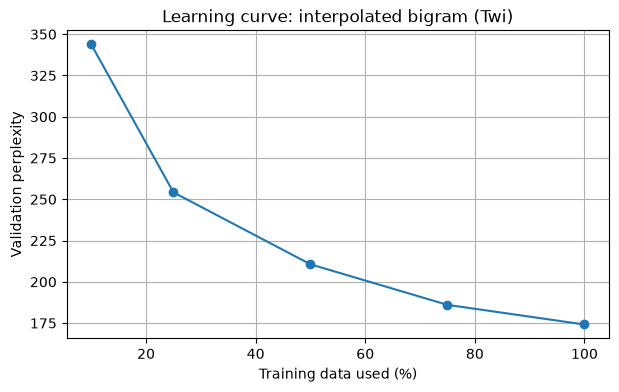

In [99]:
import random

# Build an interpolated bigram from a subset of training sentences and score it
def interp_pp_from(train_subset, eval_sents, lam=0.5):
    uni = Counter(ng for s in train_subset for ng in get_ngrams(s, 1))
    bi = Counter(ng for s in train_subset for ng in get_ngrams(s, 2))
    total = sum(uni.values()) - uni[("<s>",)]
    def prob(prev, word):
        p_uni = (uni[(word,)] + 1) / (total + V)   # add-one so words missing from a small subset never get 0
        p_bi = bi[(prev, word)] / uni[(prev,)] if uni[(prev,)] > 0 else 0.0
        return lam * p_bi + (1 - lam) * p_uni
    return perplexity(eval_sents, prob)

# Shuffle once (fixed seed = same result every run), then train on growing slices
random.seed(42)
shuffled = random.sample(train_sents, len(train_sents))
fractions = [0.1, 0.25, 0.5, 0.75, 1.0]
curve = []
for f in fractions:
    subset = shuffled[:int(f * len(shuffled))]
    pp = interp_pp_from(subset, val_sents)
    curve.append(pp)
    print(f"{int(f*100):>3}% of training data ({len(subset)} sentences): val perplexity = {pp:.1f}")

# Plot the learning curve
plt.figure(figsize=(7, 4))
plt.plot([f * 100 for f in fractions], curve, marker="o")
plt.xlabel("Training data used (%)")
plt.ylabel("Validation perplexity")
plt.title("Learning curve: interpolated bigram (Twi)")
plt.grid(True)
plt.savefig("learning_curve.png", dpi=150, bbox_inches="tight")
plt.show()


In [100]:
# Generate a sentence without <UNK> (display only: the model itself is unchanged)
def generate_sentence_no_unk(max_words=20):
    sentence = ["<s>"]
    while len(sentence) < max_words:
        prev = sentence[-1]
        # all words seen after prev in training, excluding <UNK>
        next_words = [(w2, c) for (w1, w2), c in bigram_counts.items() if w1 == prev and w2 != "<UNK>"]
        # stop if nothing is left to choose from
        if not next_words:
            break
        words, counts = zip(*next_words)
        # pick one at random, with probability proportional to its count (MLE sampling)
        next_word = random.choices(words, weights=counts)[0]
        if next_word == "</s>":
            break
        sentence.append(next_word)
    return " ".join(sentence[1:])

random.seed(1)
for i in range(5):
    print(f"{i+1}. {generate_sentence_no_unk()}")


1. wɔ dwadie amanyɔsɛm mu
2. ɔkyerɛkyerɛfo no mfa sika ho wɔse aban lɔya panin paa kwasi anin yeboah de nanso sɛ abofra bɛka biara
3. nanso awarefo bi a wɔyɛ sika a
4. prof gift mugano akyerɛ ayaresabea a wubetumi de afe sikasɛm ho a ɔman yi ɛkɔnomi ho saa nti
5. ɔsom mu sɛdeɛ ɛkwan bi a ɛbɛyɛ ade a na ɛmaa abammɔfoɔ no so wɔ 2021 sii aberɛ a
